In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.cluster import MeanShift
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
Data = pd.read_csv('Salary_Data.csv')

print(Data.head())

print(Data.shape)

print(Data.describe())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
(30, 2)
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


<Figure size 2000x1600 with 0 Axes>

<Figure size 2000x1600 with 0 Axes>

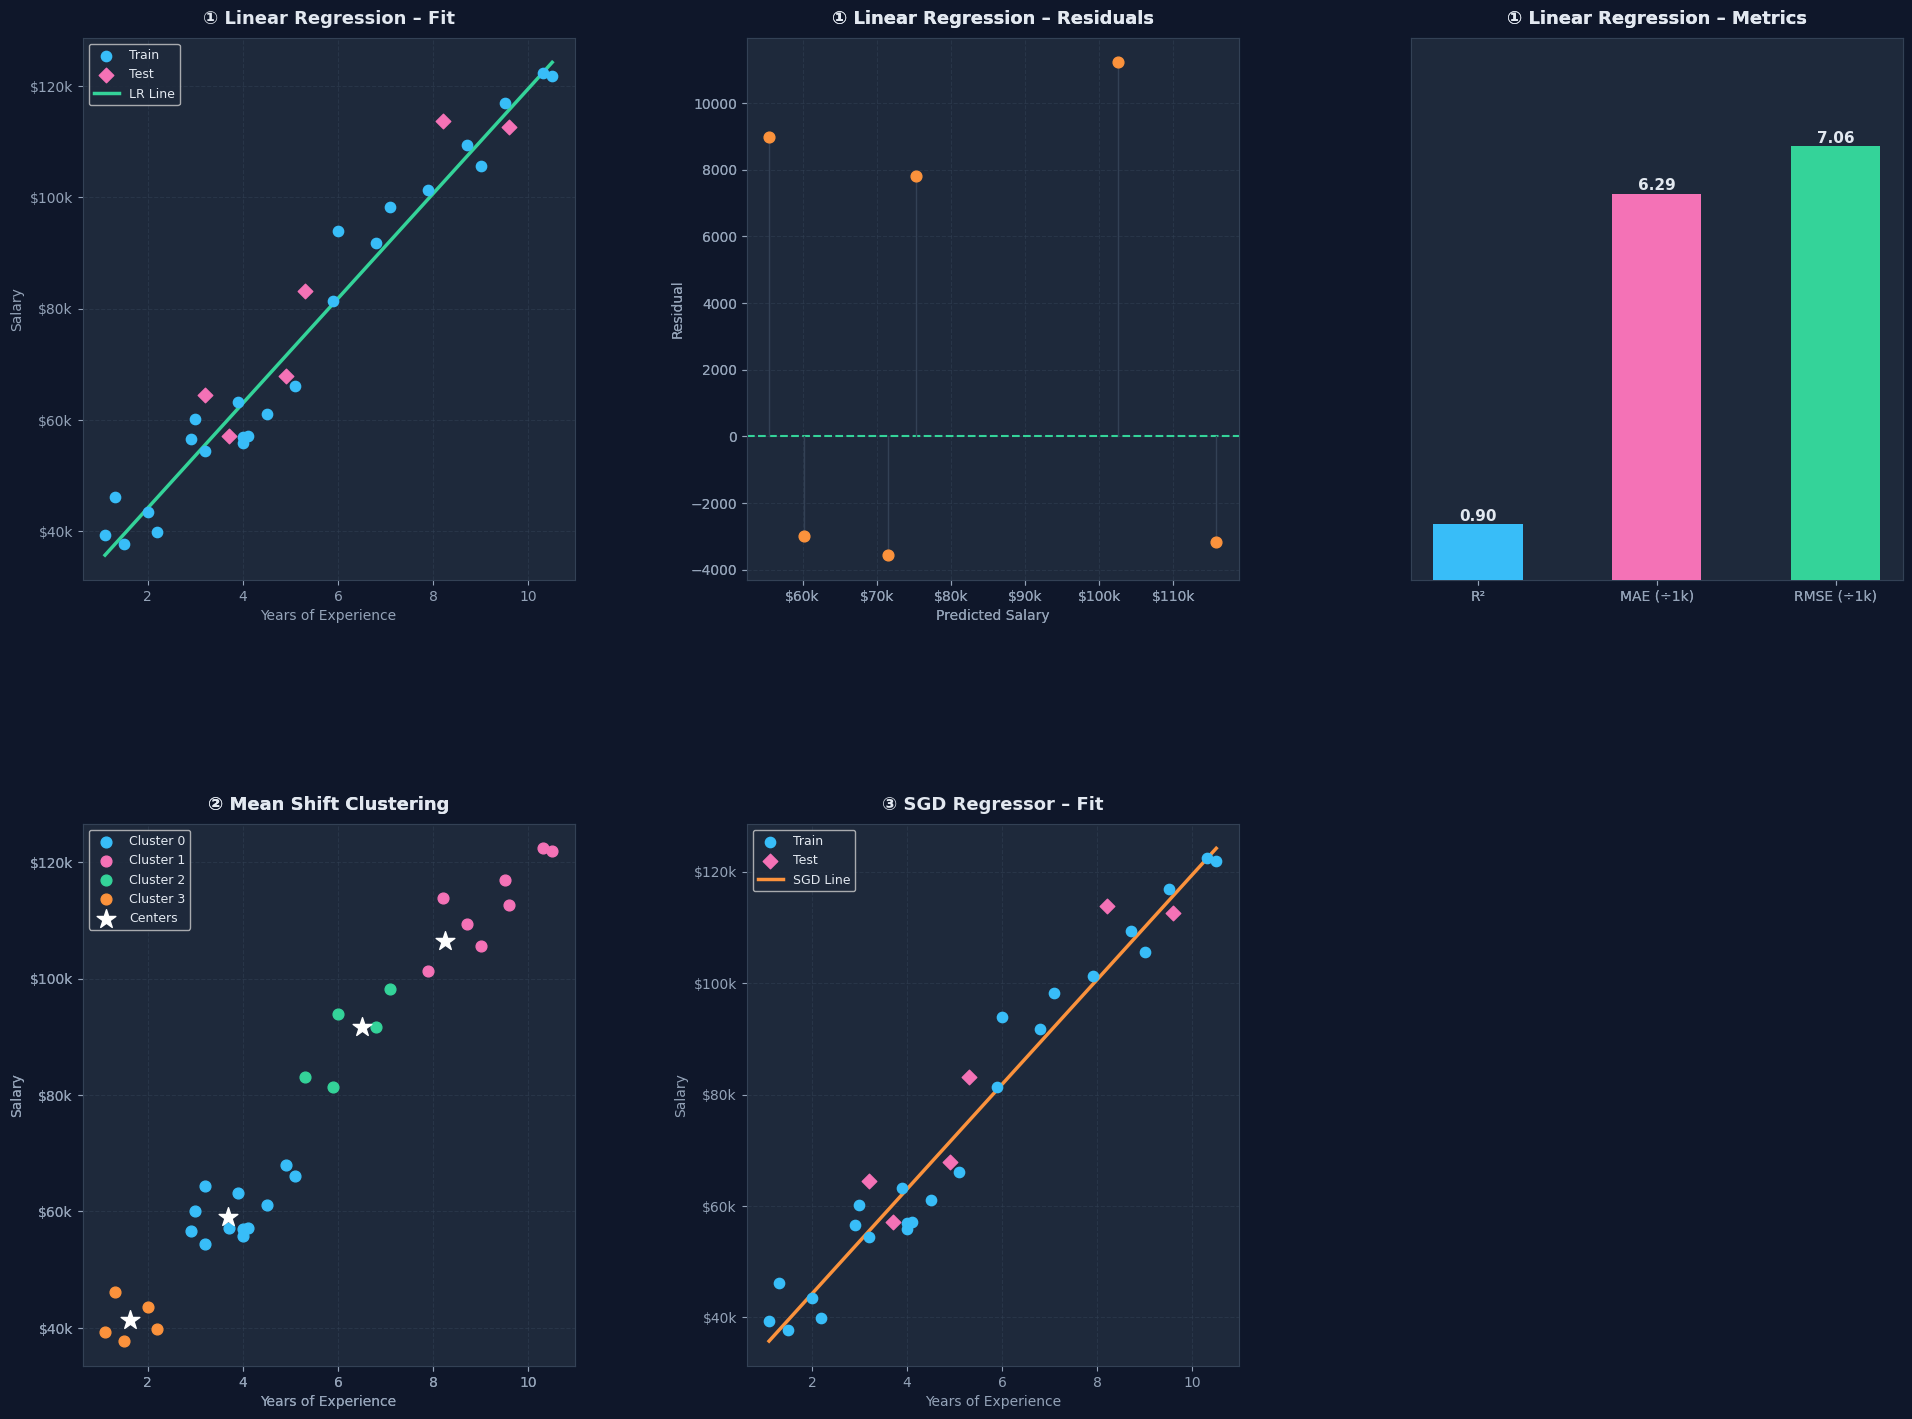

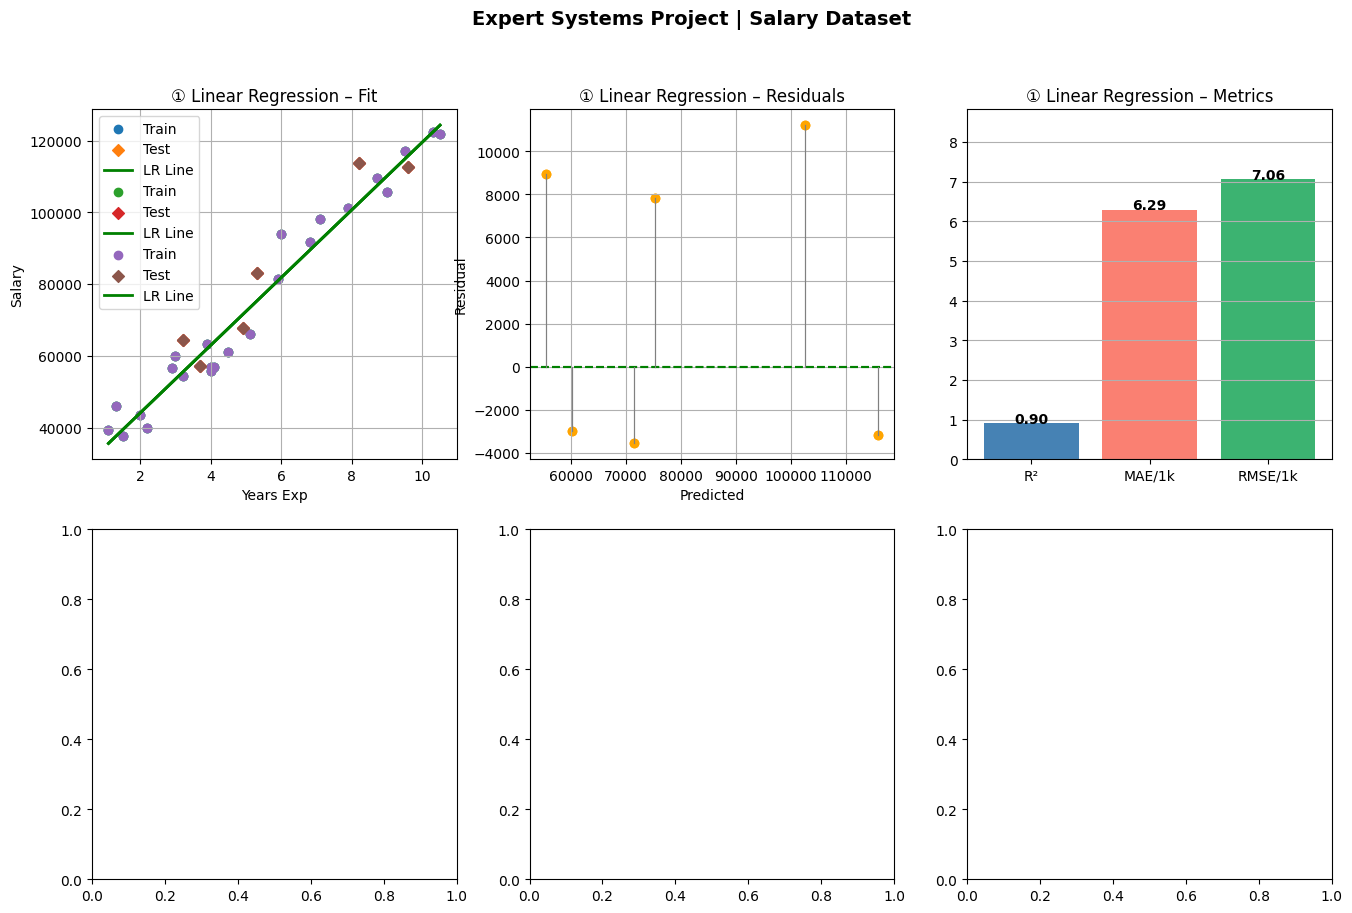

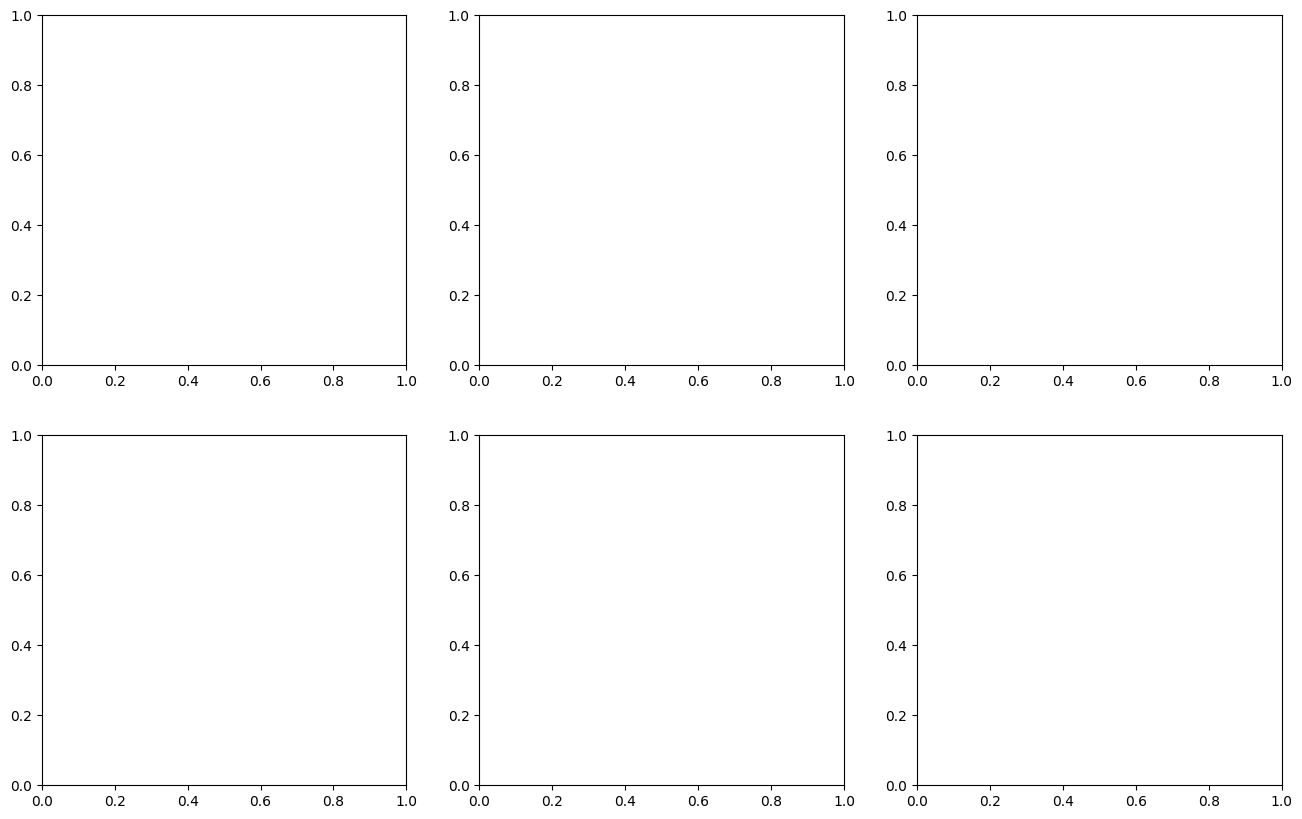

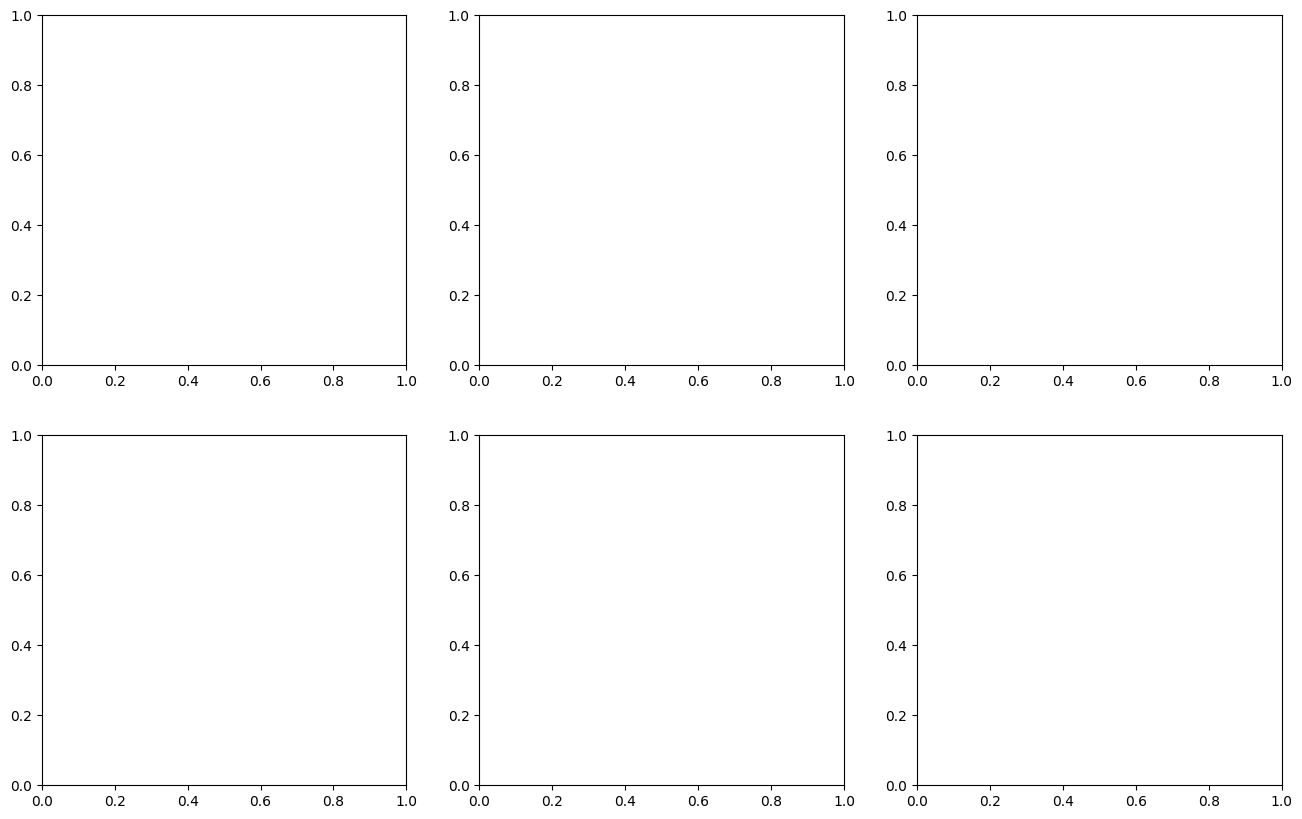

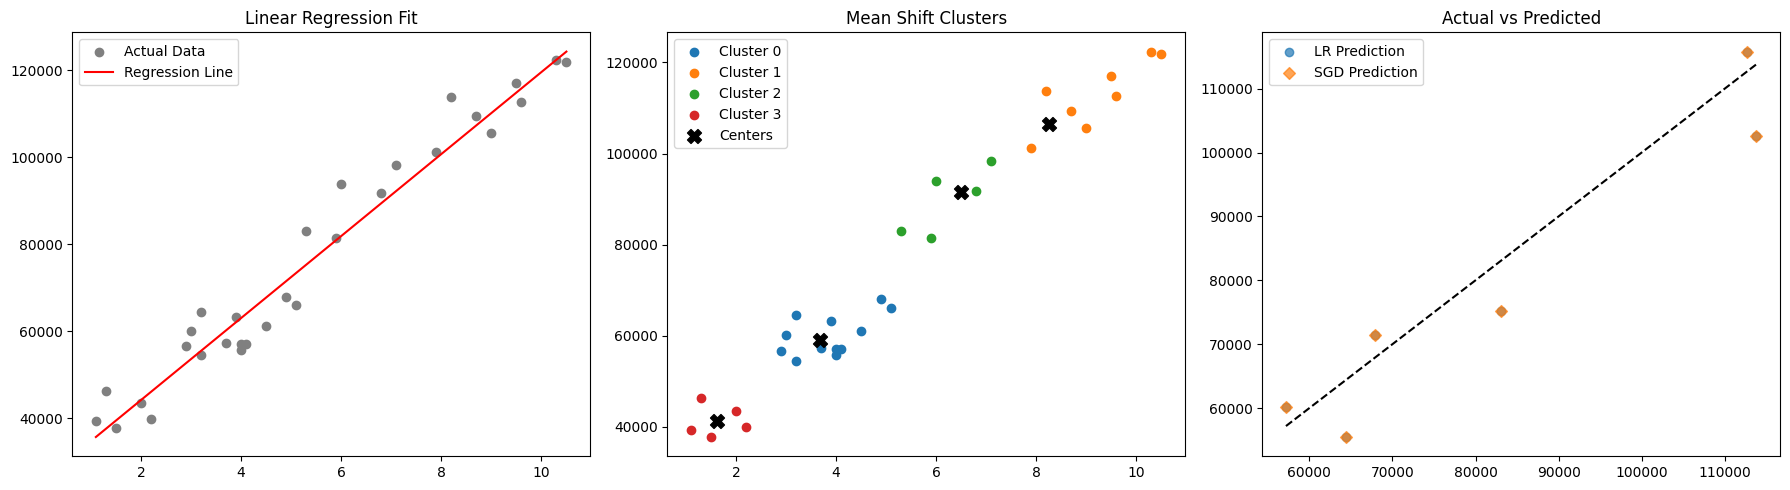

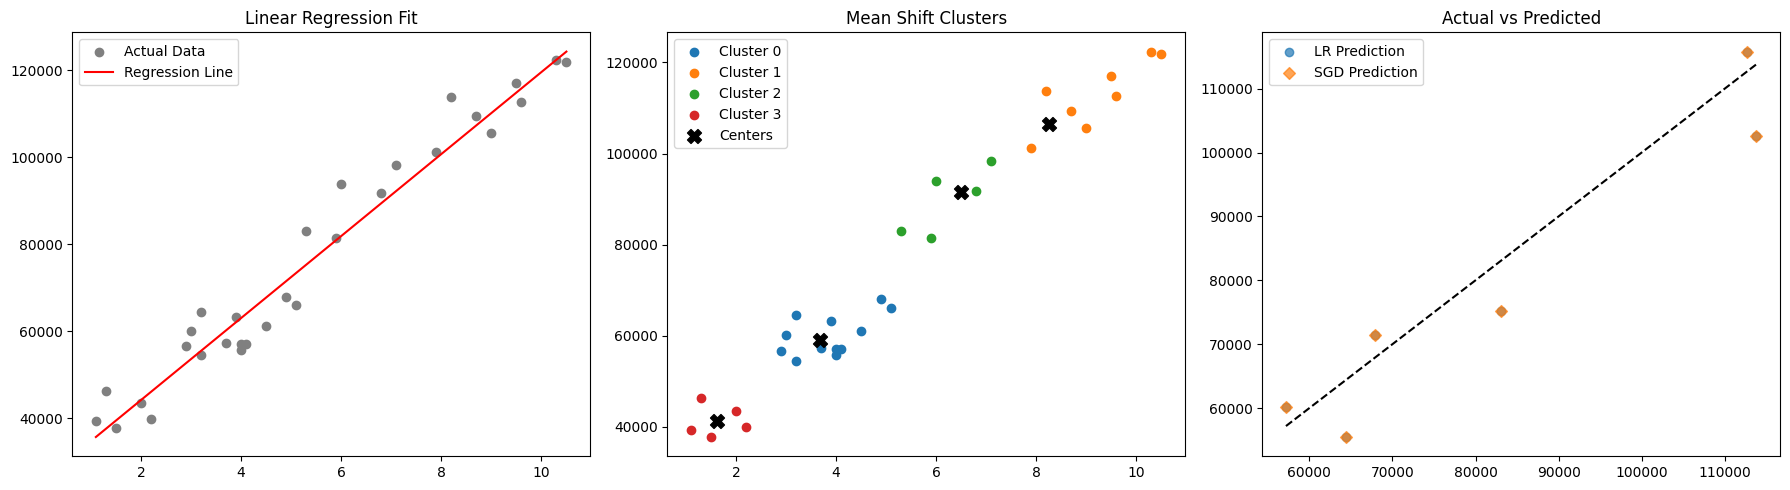

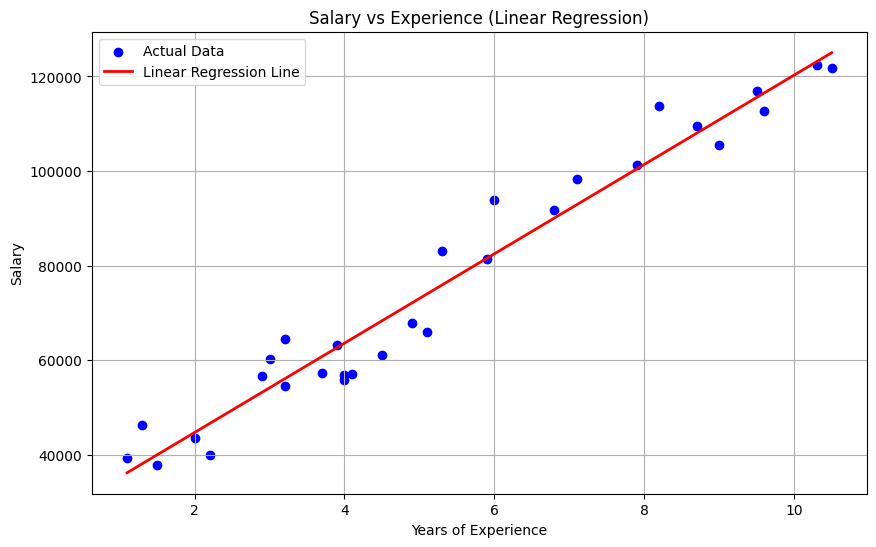

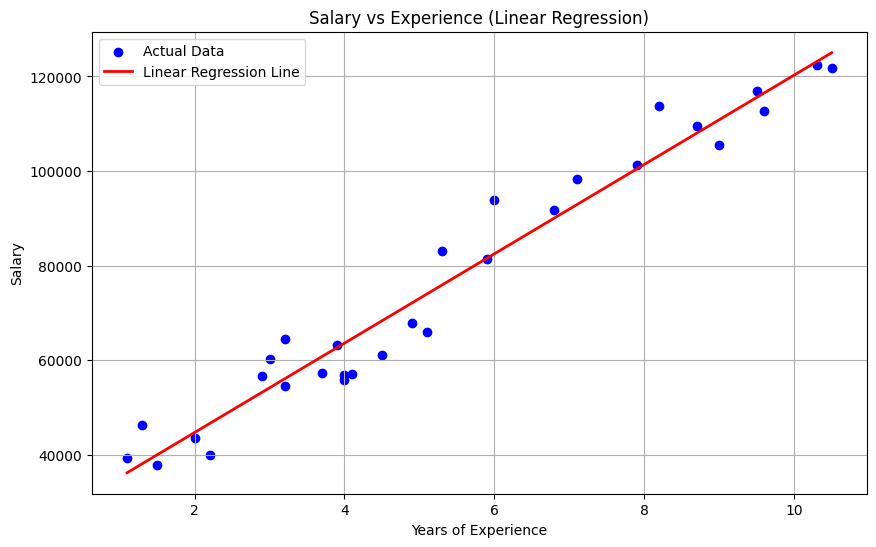

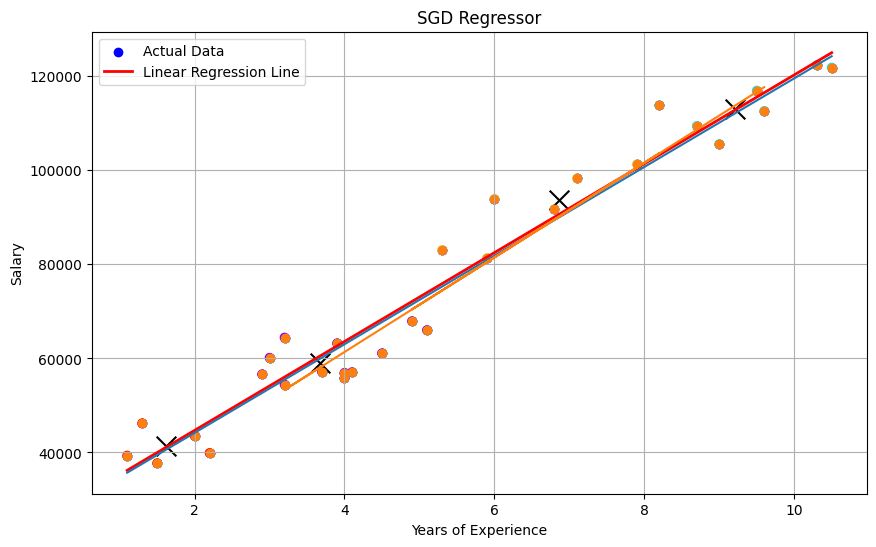

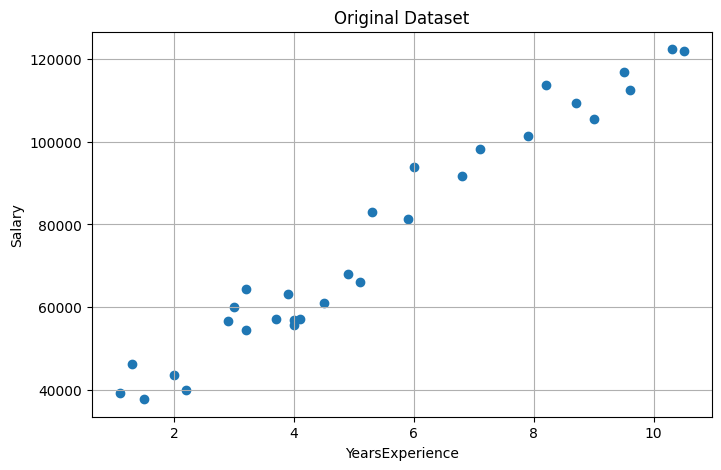

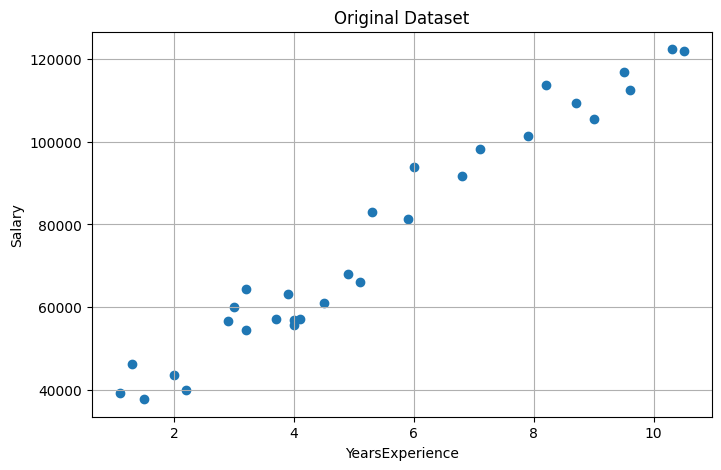

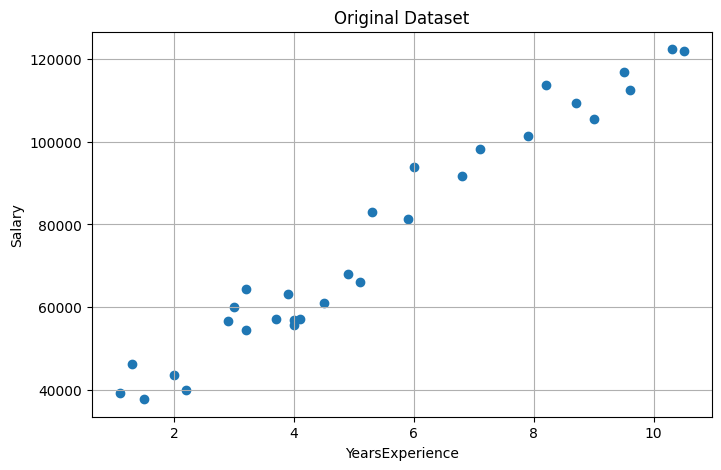

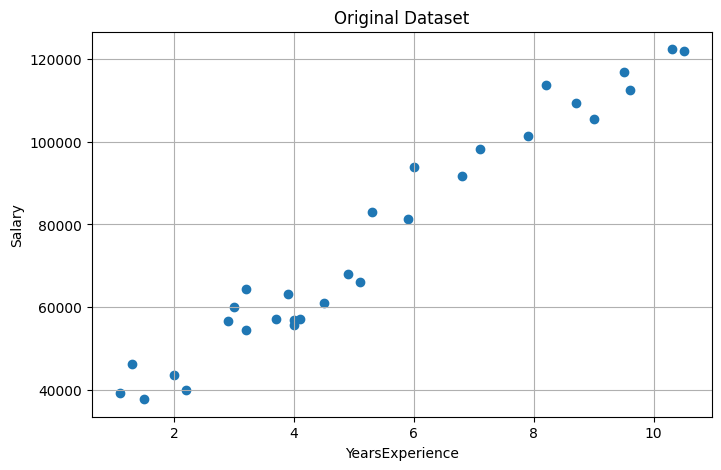

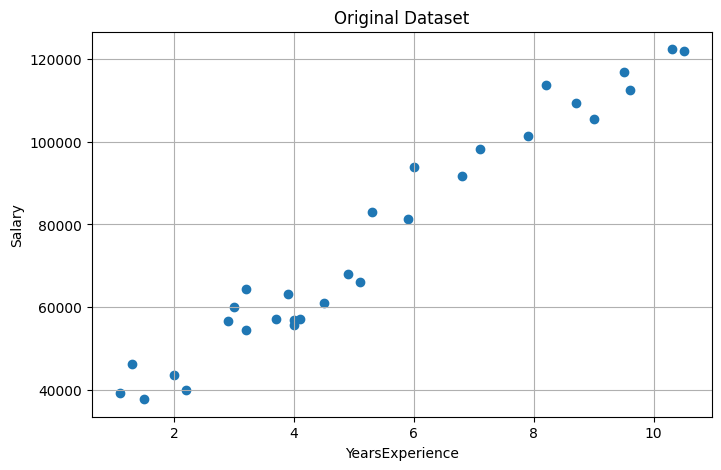

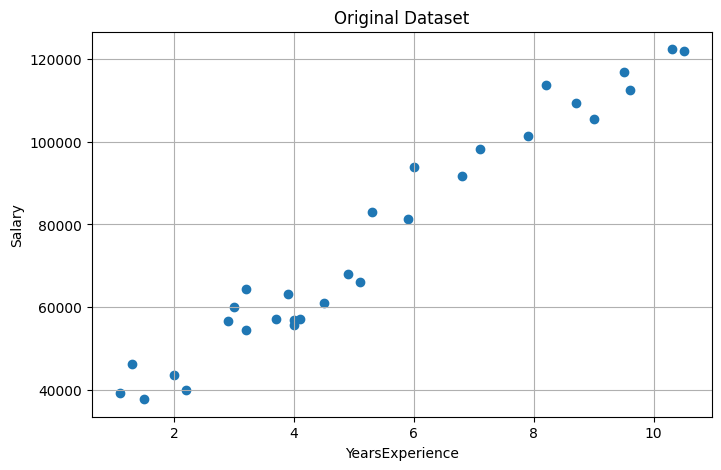

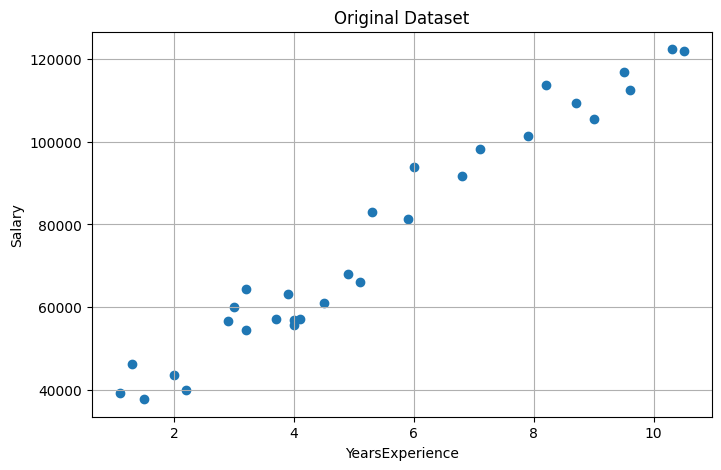

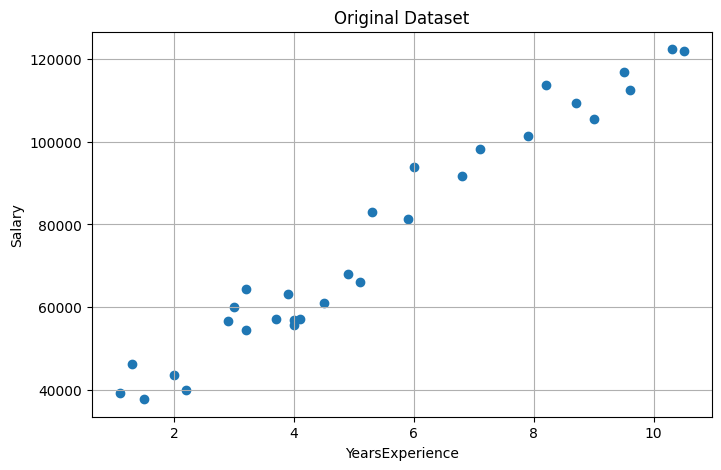

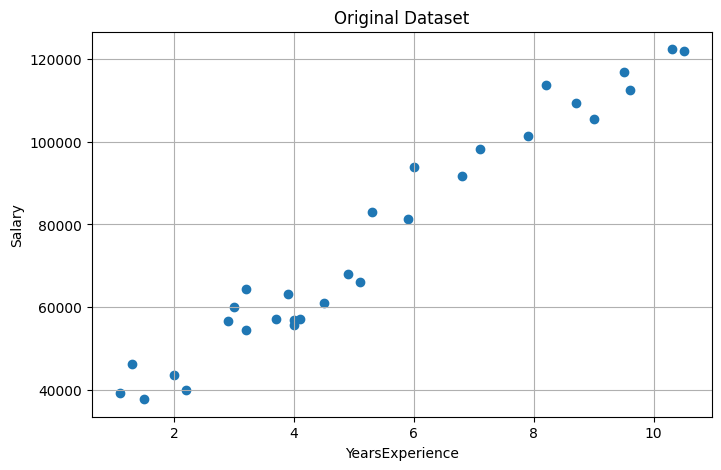

In [46]:
%matplotlib inline
plt.figure(figsize=(8,5))

plt.scatter(
    Data['YearsExperience'].values,
    Data['Salary'].values
)

plt.title('Original Dataset')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.grid(True)

plt.show()

In [47]:
X = Data[['YearsExperience']]
y = Data['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
LR_Model = LinearRegression()

LR_Model.fit(X_train, y_train)

y_pred = LR_Model.predict(X_test)

print('MSE = ', mean_squared_error(y_test, y_pred))
print('R2 Score = ', r2_score(y_test, y_pred))

print('Slope = ', LR_Model.coef_[0])
print('Intercept = ', LR_Model.intercept_)

MSE =  49830096.85590839
R2 Score =  0.9024461774180497
Slope =  9423.815323030976
Intercept =  25321.583011776813


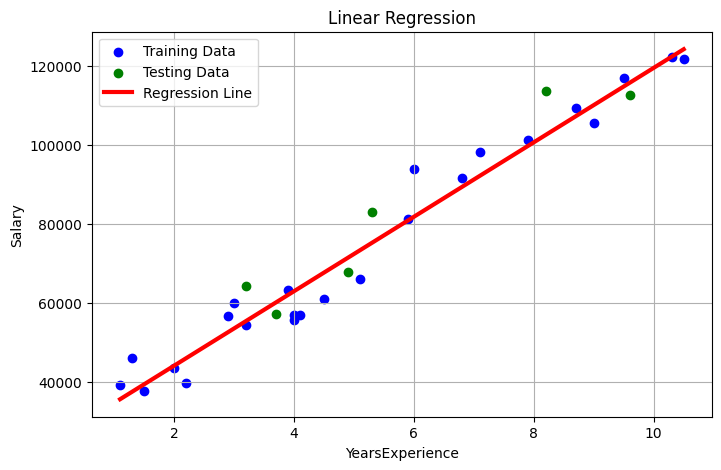

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train,
    y_train,
    color='blue',
    label='Training Data'
)

plt.scatter(
    X_test,
    y_test,
    color='green',
    label='Testing Data'
)

plt.plot(
    X,
    LR_Model.predict(X),
    color='red',
    linewidth=3,
    label='Regression Line'
)

plt.title('Linear Regression')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.legend()

plt.grid(True)

plt.show()

In [50]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

print(comparison)

    Actual Salary  Predicted Salary
27       112635.0     115790.210113
15        67938.0      71498.278095
23       113812.0     102596.868661
17        83088.0      75267.804224
8         64445.0      55477.792045
9         57189.0      60189.699707


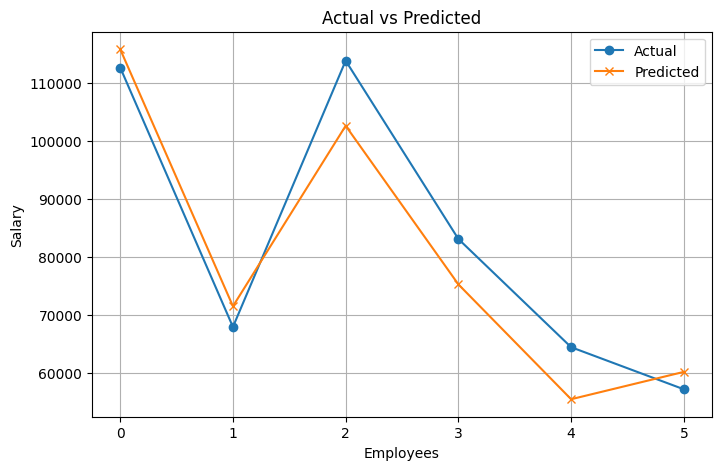

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='x',
    label='Predicted'
)

plt.title('Actual vs Predicted')
plt.xlabel('Employees')
plt.ylabel('Salary')

plt.legend()

plt.grid(True)

plt.show()

In [52]:
X_cluster = Data[['YearsExperience', 'Salary']]

MS_Model = MeanShift()

MS_Model.fit(X_cluster)

labels = MS_Model.labels_

cluster_centers = MS_Model.cluster_centers_

print(labels)

print(cluster_centers)

print('Number of Clusters = ', len(np.unique(labels)))

[3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 1 1 1 1 1 1 1]
[[3.67692308e+00 5.90156923e+04]
 [9.21250000e+00 1.12999250e+05]
 [6.85714286e+00 9.36122857e+04]
 [1.62000000e+00 4.13390000e+04]]
Number of Clusters =  4


In [53]:
Data['Cluster'] = labels

print(Data)

    YearsExperience    Salary  Cluster
0               1.1   39343.0        3
1               1.3   46205.0        3
2               1.5   37731.0        3
3               2.0   43525.0        3
4               2.2   39891.0        3
5               2.9   56642.0        0
6               3.0   60150.0        0
7               3.2   54445.0        0
8               3.2   64445.0        0
9               3.7   57189.0        0
10              3.9   63218.0        0
11              4.0   55794.0        0
12              4.0   56957.0        0
13              4.1   57081.0        0
14              4.5   61111.0        0
15              4.9   67938.0        0
16              5.1   66029.0        0
17              5.3   83088.0        2
18              5.9   81363.0        2
19              6.0   93940.0        2
20              6.8   91738.0        2
21              7.1   98273.0        2
22              7.9  101302.0        2
23              8.2  113812.0        1
24              8.7  1094

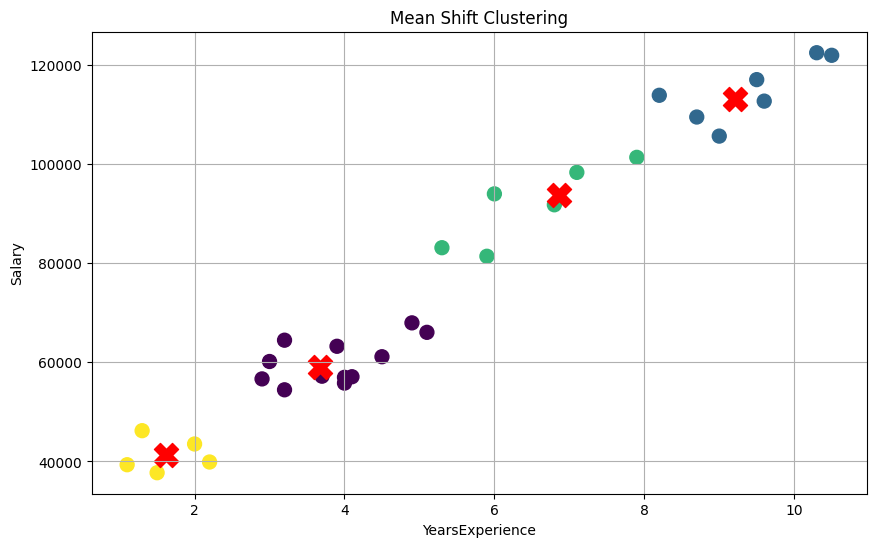

In [54]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_cluster['YearsExperience'],
    X_cluster['Salary'],
    c=labels,
    cmap='viridis',
    s=100
)

plt.scatter(
    cluster_centers[:,0],
    cluster_centers[:,1],
    color='red',
    marker='X',
    s=300
)

plt.title('Mean Shift Clustering')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.grid(True)

plt.show()

In [55]:
SGD_Model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

SGD_Model.fit(X_train, y_train)

y_pred_sgd = SGD_Model.predict(X_test)

print('MSE = ', mean_squared_error(y_test, y_pred_sgd))
print('R2 Score = ', r2_score(y_test, y_pred_sgd))

print('Coefficient = ', SGD_Model.coef_)
print('Intercept = ', SGD_Model.intercept_)

MSE =  55996200.05069832
R2 Score =  0.8903746187609204
Coefficient =  [10059.7175123]
Intercept =  [21119.04444681]


In [56]:
sgd_comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred_sgd
})

print(sgd_comparison)

    Actual Salary  Predicted Salary
27       112635.0     117692.332565
15        67938.0      70411.660257
23       113812.0     103608.728048
17        83088.0      74435.547262
8         64445.0      53310.140486
9         57189.0      58339.999242


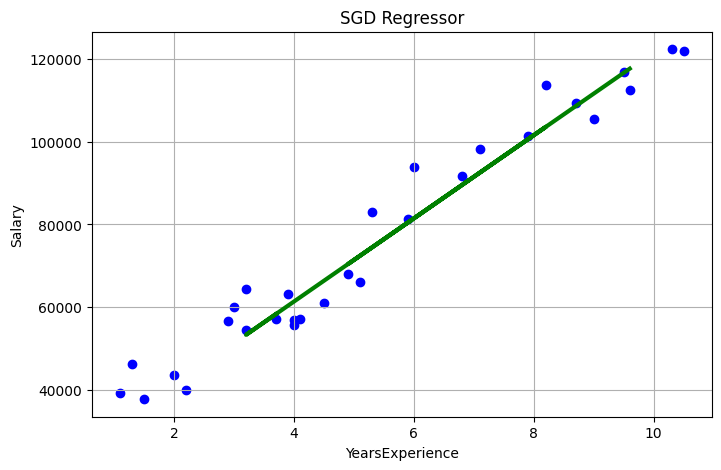

In [57]:
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color='blue'
)

plt.plot(
    X_test,
    y_pred_sgd,
    color='green',
    linewidth=3
)

plt.title('SGD Regressor')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

plt.grid(True)

plt.show()

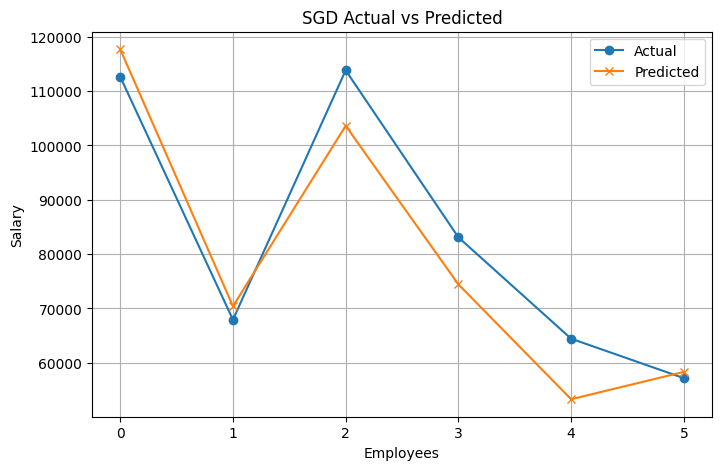

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(y_pred_sgd)),
    y_pred_sgd,
    marker='x',
    label='Predicted'
)

plt.title('SGD Actual vs Predicted')
plt.xlabel('Employees')
plt.ylabel('Salary')

plt.legend()

plt.grid(True)

plt.show()